# Phase Error
In this note, we will look into the different types of phase errors and the effects on a signal. To start off we will emit a finite chirp signal in time domain and plot its frequency representation.

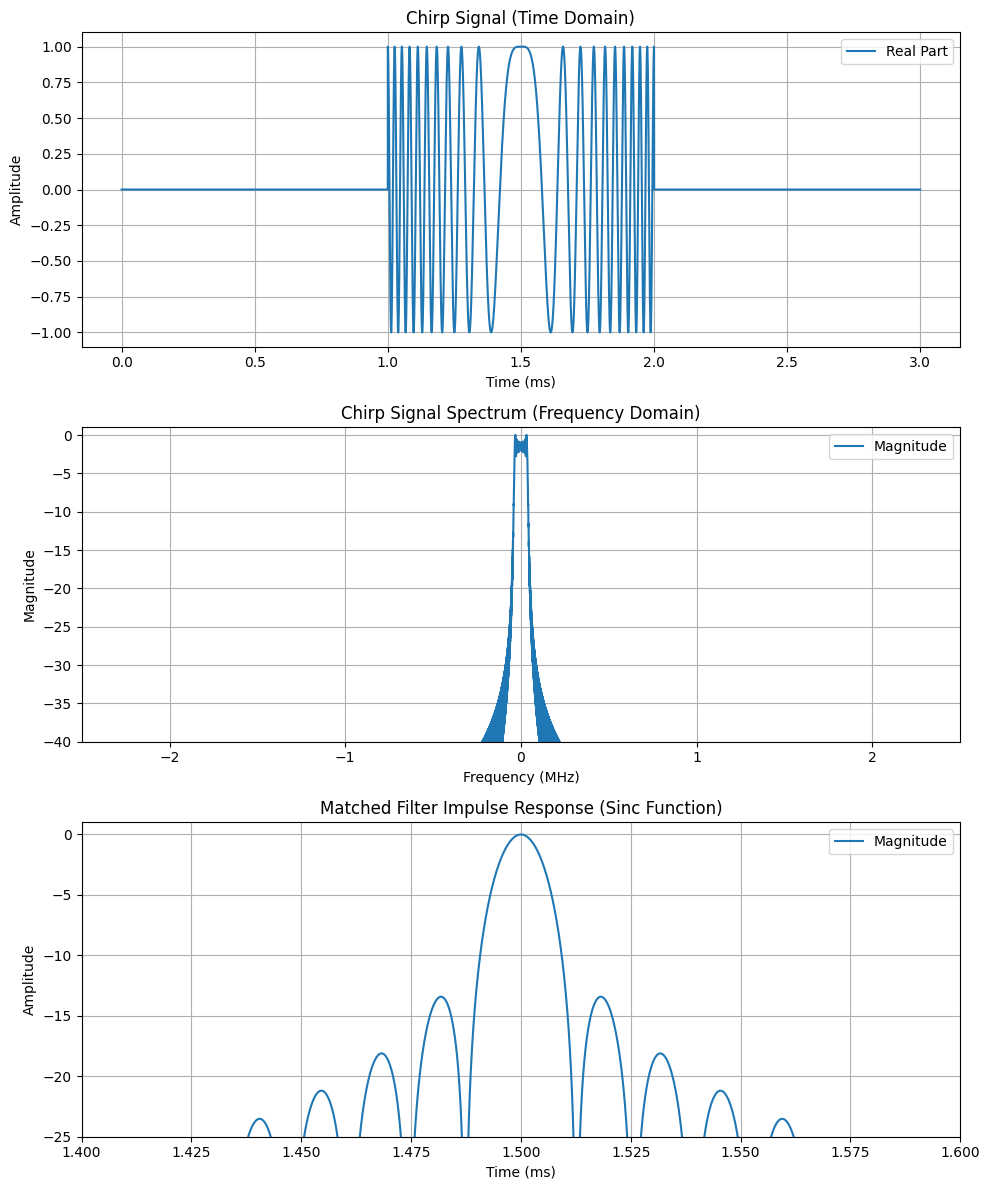

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal.windows import taylor

pulse_width = 1e-3  # Pulse width (seconds)
fs = 20e6           # Sampling frequency (Hz)

total_time = 3e-3         # Total time span (seconds)
N = int(total_time * fs)  # Total number of samples
time_axis = np.linspace(0, total_time, N, endpoint=False)

chirp_rate = 8e7   # Chirp rate (Hz/s)

# Define pulse window: chirp is on between t0 and t0 + pulse_width
t0 = 1e-3  # Pulse start time (seconds)
window = ((time_axis >= t0) & (time_axis <= t0 + pulse_width)).astype(float)

# Base chirp (centred within the pulse)
t_centered = time_axis - (t0 + pulse_width / 2)
chirp_base = np.exp(1j * (np.pi * chirp_rate * t_centered**2))

chirp_signal_t = chirp_base * window

chirp_signal_f = np.fft.fftshift(np.fft.fft(chirp_signal_t))
freq_axis = np.fft.fftshift(
    np.fft.fftfreq(len(time_axis), d=(time_axis[1] - time_axis[0]))
)

# Matched filtering: multiply spectrum by complex conjugate of reference
matched_filter_f = chirp_signal_f * np.conj(chirp_signal_f)
matched_filter_t = np.fft.ifft(np.fft.ifftshift(matched_filter_f))

# Plot the chirp signal in time and frequency domains, plus matched filter output
plt.figure(figsize=(10, 12))

# Time-domain subplot
plt.subplot(3, 1, 1)
plt.plot(time_axis * 1e3, np.real(chirp_signal_t), label='Real Part')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.title('Chirp Signal (Time Domain)')
plt.grid(True)
plt.legend()

# Frequency-domain subplot
plt.subplot(3, 1, 2)
plt.plot(freq_axis / 1e6, 20 * np.log10(np.abs(chirp_signal_f)/np.abs(chirp_signal_f).max()), label='Magnitude')
plt.xlim(-2.5, 2.5)
plt.ylim(-40, 1)
plt.xlabel('Frequency (MHz)')
plt.ylabel('Magnitude')
plt.title('Chirp Signal Spectrum (Frequency Domain)')
plt.grid(True)
plt.legend()

max_mag = np.abs(matched_filter_t).max()

# Matched filter impulse response
plt.subplot(3, 1, 3)
plt.plot(time_axis * 1e3, (20 * np.log10(np.fft.fftshift(np.abs(matched_filter_t)/max_mag))), label='Magnitude')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.xlim(1.4,1.6)
plt.ylim(-25,1)
plt.title('Matched Filter Impulse Response (Sinc Function)')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Adding Linear Phase Error

Here we add a phase term that is **linear in frequency**:



$$\phi_{\text{lin}}(f) = a\,(f - f_c)$$



and apply it by multiplying the complex baseband signal by



$$s_{\text{err}}(f) = s(f)\, e^{j\,\phi_{\text{lin}}(f)}.$$


It mimics a frequency offset / LO error / Doppler shift.

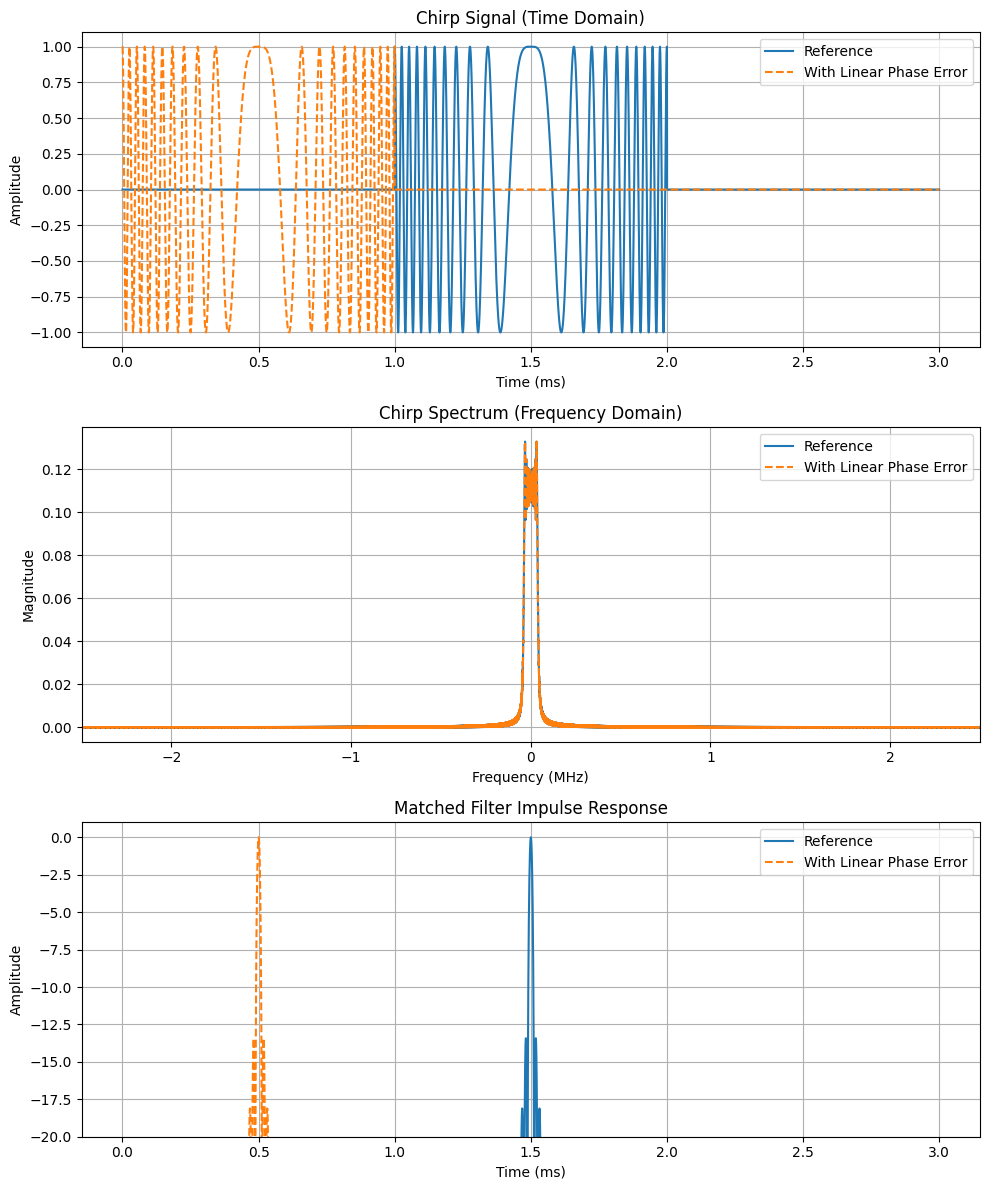

In [49]:
# Linear phase error (in frequency)
a = 2 * np.pi * 1e5   # radians per second (slope)
phi0 = 0.0            # constant offset

t_c = t0 + pulse_width / 2  # centre of pulse

freq_axis = np.fft.fftshift(
    np.fft.fftfreq(len(time_axis), d=(time_axis[1] - time_axis[0]))
)
phi_lin = a * (freq_axis - chirp_rate * t_c) + phi0

# Apply linear phase error
chirp_signal_f_lin = np.fft.fftshift(np.fft.fft(chirp_signal_t))
chirp_signal_f_lin *= np.exp(1j * phi_lin)
chirp_signal_t_lin = np.fft.ifft(np.fft.ifftshift(chirp_signal_f_lin))

# Matched filter outputs
matched_filter_ref_f = chirp_signal_f * np.conj(chirp_signal_f)
matched_filter_ref_t = np.fft.ifft(np.fft.ifftshift(matched_filter_ref_f))

matched_filter_lin_f = chirp_signal_f_lin * np.conj(chirp_signal_f)
matched_filter_lin_t = np.fft.ifft(np.fft.ifftshift(matched_filter_lin_f))

# Plot reference vs. with linear phase error
plt.figure(figsize=(10, 12))

# Time-domain: reference vs with error
plt.subplot(3, 1, 1)
plt.plot(time_axis * 1e3, np.real(chirp_signal_t), label='Reference')
plt.plot(time_axis * 1e3, np.real(chirp_signal_t_lin), '--', label='With Linear Phase Error')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.title('Chirp Signal (Time Domain)')
plt.grid(True)
plt.legend()
2
# Frequency-domain: reference vs with error
plt.subplot(3, 1, 2)
plt.plot(freq_axis / 1e6, np.abs(chirp_signal_f / max_mag), label='Reference')
plt.plot(freq_axis / 1e6, np.abs(chirp_signal_f_lin / max_mag), '--', label='With Linear Phase Error')
plt.xlim(-2.5, 2.5)
plt.xlabel('Frequency (MHz)')
plt.ylabel('Magnitude')
plt.title('Chirp Spectrum (Frequency Domain)')
plt.grid(True)
plt.legend()

# Matched filter impulse response
plt.subplot(3, 1, 3)
plt.plot(time_axis * 1e3, 20 * np.log10(np.fft.fftshift(np.abs(matched_filter_ref_t) / max_mag)), label='Reference')
plt.plot(time_axis * 1e3, 20 * np.log10(np.fft.fftshift(np.abs(matched_filter_lin_t / max_mag))), '--', label='With Linear Phase Error')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.ylim(-20, 1)
plt.title('Matched Filter Impulse Response')
plt.grid(True)
plt.legend()
plt.tight_layout()

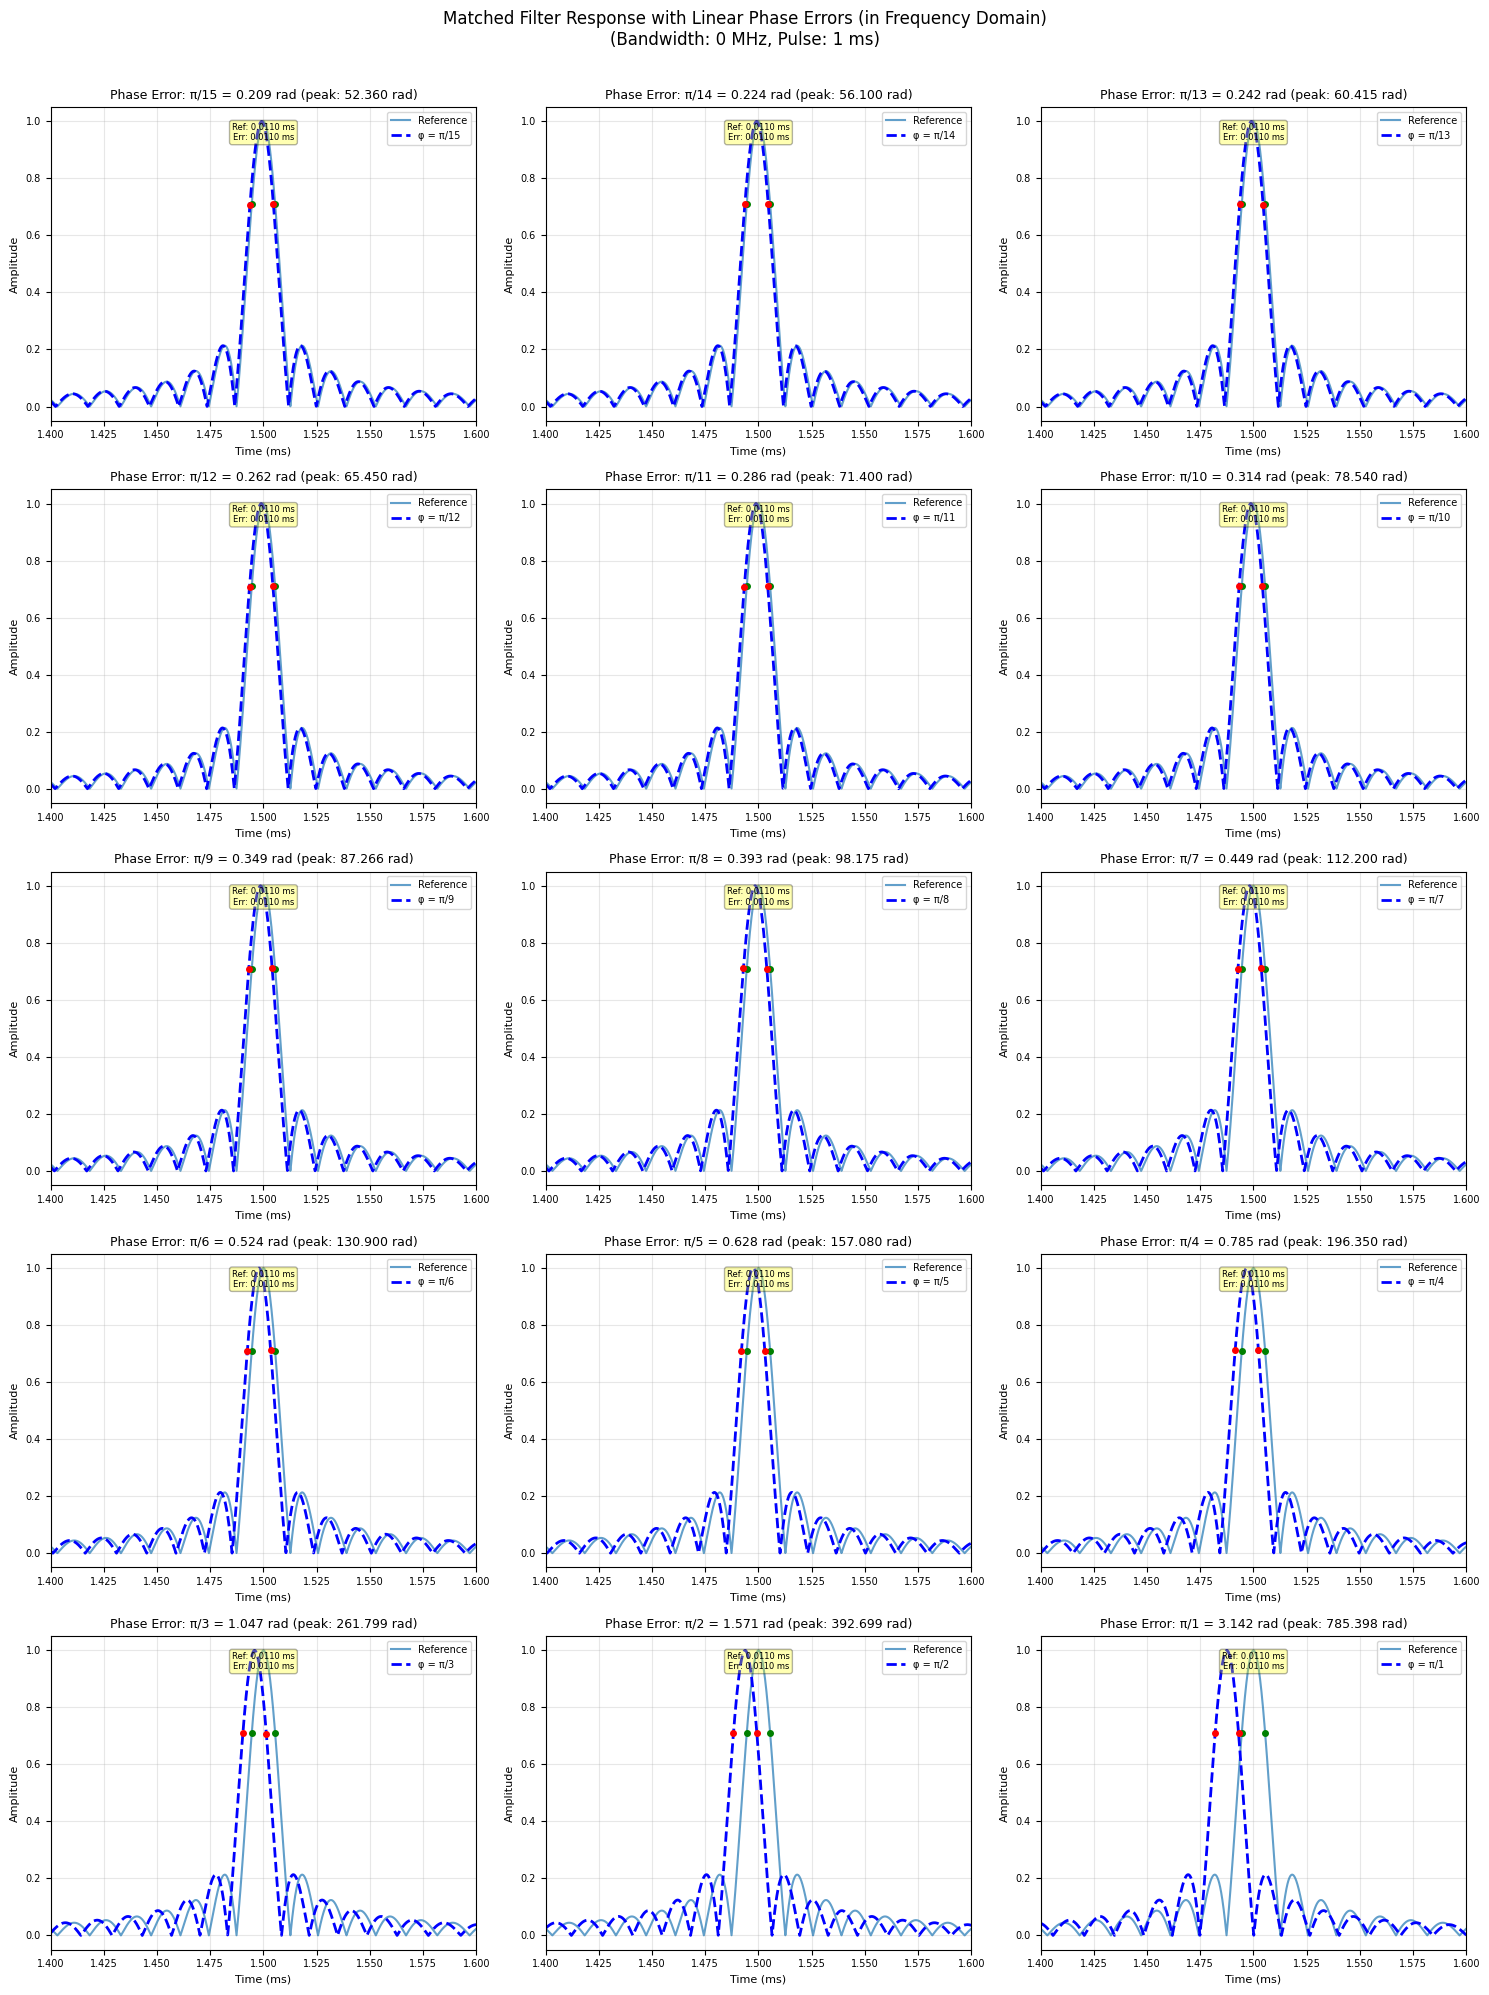

Signal bandwidth: 0.1 MHz
Maximum frequency: 0.0 MHz


In [50]:
# Generate plots for phase errors: π/2, π/3, π/4, ..., π/16
phase_labels = [i for i in range(15,0,-1)]
phase_errors = [np.pi/n for n in phase_labels]

# Calculate bandwidth to determine appropriate coefficients
bandwidth = chirp_rate * pulse_width  # Hz
f_max = bandwidth / 2
f_c = 0  # Centre frequency

# Create figure with subplots
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()

for idx, (phase_err, n) in enumerate(zip(phase_errors, phase_labels)):
    # Calculate linear coefficient to achieve target phase error at f_max
    lin_coeff = phase_err / f_max
    
    # Frequency axis
    freq_axis_local = np.fft.fftshift(
        np.fft.fftfreq(len(time_axis), d=(time_axis[1] - time_axis[0]))
    )
    phi_lin_local = lin_coeff * (freq_axis_local - f_c)
    
    # Apply linear phase error in frequency domain
    chirp_signal_f_lin = np.fft.fftshift(np.fft.fft(chirp_signal_t))
    chirp_signal_f_lin *= np.exp(1j * phi_lin_local)
    
    # Matched filter outputs
    matched_filter_ref_f = chirp_signal_f * np.conj(chirp_signal_f)
    matched_filter_ref_t = np.fft.ifft(np.fft.ifftshift(matched_filter_ref_f))
    
    matched_filter_lin_f = chirp_signal_f_lin * np.conj(chirp_signal_f)
    matched_filter_lin_t = np.fft.ifft(np.fft.ifftshift(matched_filter_lin_f))
    
    # Calculate actual peak phase error achieved
    peak_phase = np.max(np.abs(phi_lin_local))
    
    # Plot matched filter impulse response
    ax = axes[idx]
    ref_shifted = np.fft.fftshift(np.abs(matched_filter_ref_t / max_mag))
    lin_shifted = np.fft.fftshift(np.abs(matched_filter_lin_t / max_mag))
    
    # Plot the signals
    ax.plot(time_axis * 1e3, ref_shifted, label='Reference', alpha=0.7, linewidth=1.5)
    ax.plot(time_axis * 1e3, lin_shifted, '--', 
            label=f'φ = π/{n}', linewidth=2, color='blue')
    
    # Calculate 3dB points for reference signal
    ref_shifted_db = 20 * np.log10(ref_shifted / np.max(ref_shifted))
    threshold_3db = -3.0
    above_3db_ref = ref_shifted_db >= threshold_3db
    
    if np.any(above_3db_ref):
        indices_3db_ref = np.where(above_3db_ref)[0]
        if len(indices_3db_ref) > 1:
            idx_left_ref = indices_3db_ref[0]
            idx_right_ref = indices_3db_ref[-1]
            t_left_ref = time_axis[idx_left_ref] * 1e3
            t_right_ref = time_axis[idx_right_ref] * 1e3
            width_3db_ref = t_right_ref - t_left_ref
            
            # Mark 3dB points for reference
            ax.plot([t_left_ref, t_right_ref], 
                    [ref_shifted[idx_left_ref], ref_shifted[idx_right_ref]], 
                    'go', markersize=4)
    
    # Calculate 3dB points for phase error signal
    lin_shifted_db = 20 * np.log10(lin_shifted / np.max(lin_shifted))
    above_3db_lin = lin_shifted_db >= threshold_3db
    
    if np.any(above_3db_lin):
        indices_3db_lin = np.where(above_3db_lin)[0]
        if len(indices_3db_lin) > 1:
            idx_left_lin = indices_3db_lin[0]
            idx_right_lin = indices_3db_lin[-1]
            t_left_lin = time_axis[idx_left_lin] * 1e3
            t_right_lin = time_axis[idx_right_lin] * 1e3
            width_3db_lin = t_right_lin - t_left_lin
            
            # Mark 3dB points for phase error
            ax.plot([t_left_lin, t_right_lin], 
                    [lin_shifted[idx_left_lin], lin_shifted[idx_right_lin]], 
                    'ro', markersize=4)
            
            # Add 3dB width annotations
            if np.any(above_3db_ref) and len(indices_3db_ref) > 1:
                ax.annotate(f'Ref: {width_3db_ref:.4f} ms\nErr: {width_3db_lin:.4f} ms', 
                            xy=(0.5, 0.95), xycoords='axes fraction',
                            fontsize=6, ha='center', va='top',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            else:
                ax.annotate(f'Err: {width_3db_lin:.4f} ms', 
                            xy=(0.5, 0.95), xycoords='axes fraction',
                            fontsize=7, ha='center', va='top',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.set_xlim(1.4, 1.6)
    ax.set_title(f'Phase Error: π/{n} = {phase_err:.3f} rad (peak: {peak_phase:.3f} rad)', 
                fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle(f'Matched Filter Response with Linear Phase Errors (in Frequency Domain)\n' + 
            f'(Bandwidth: {bandwidth/1e6:.0f} MHz, Pulse: {pulse_width*1e3:.0f} ms)', 
            fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print(f"Signal bandwidth: {bandwidth/1e6:.1f} MHz")
print(f"Maximum frequency: {f_max/1e6:.1f} MHz")

It is observed that with the linear phase error introduction in the time domain, we will see a shift in the frequency domain by $f_0$ and a shift in the time domain as well for the REAL part.

# Adding Quadratic Phase Error


Here we add a phase term that is **quadratic in frequency**:



$$\phi_{\text{quad}}(f) = b\,(f - f_c)^2$$



and apply it by multiplying the complex baseband signal by



$$s_{\text{err}}(f) = s(f)\, e^{j\,\phi_{\text{quad}}(f)}.$$



This mimics a quadratic phase distortion (e.g. residual chirp or dispersion).

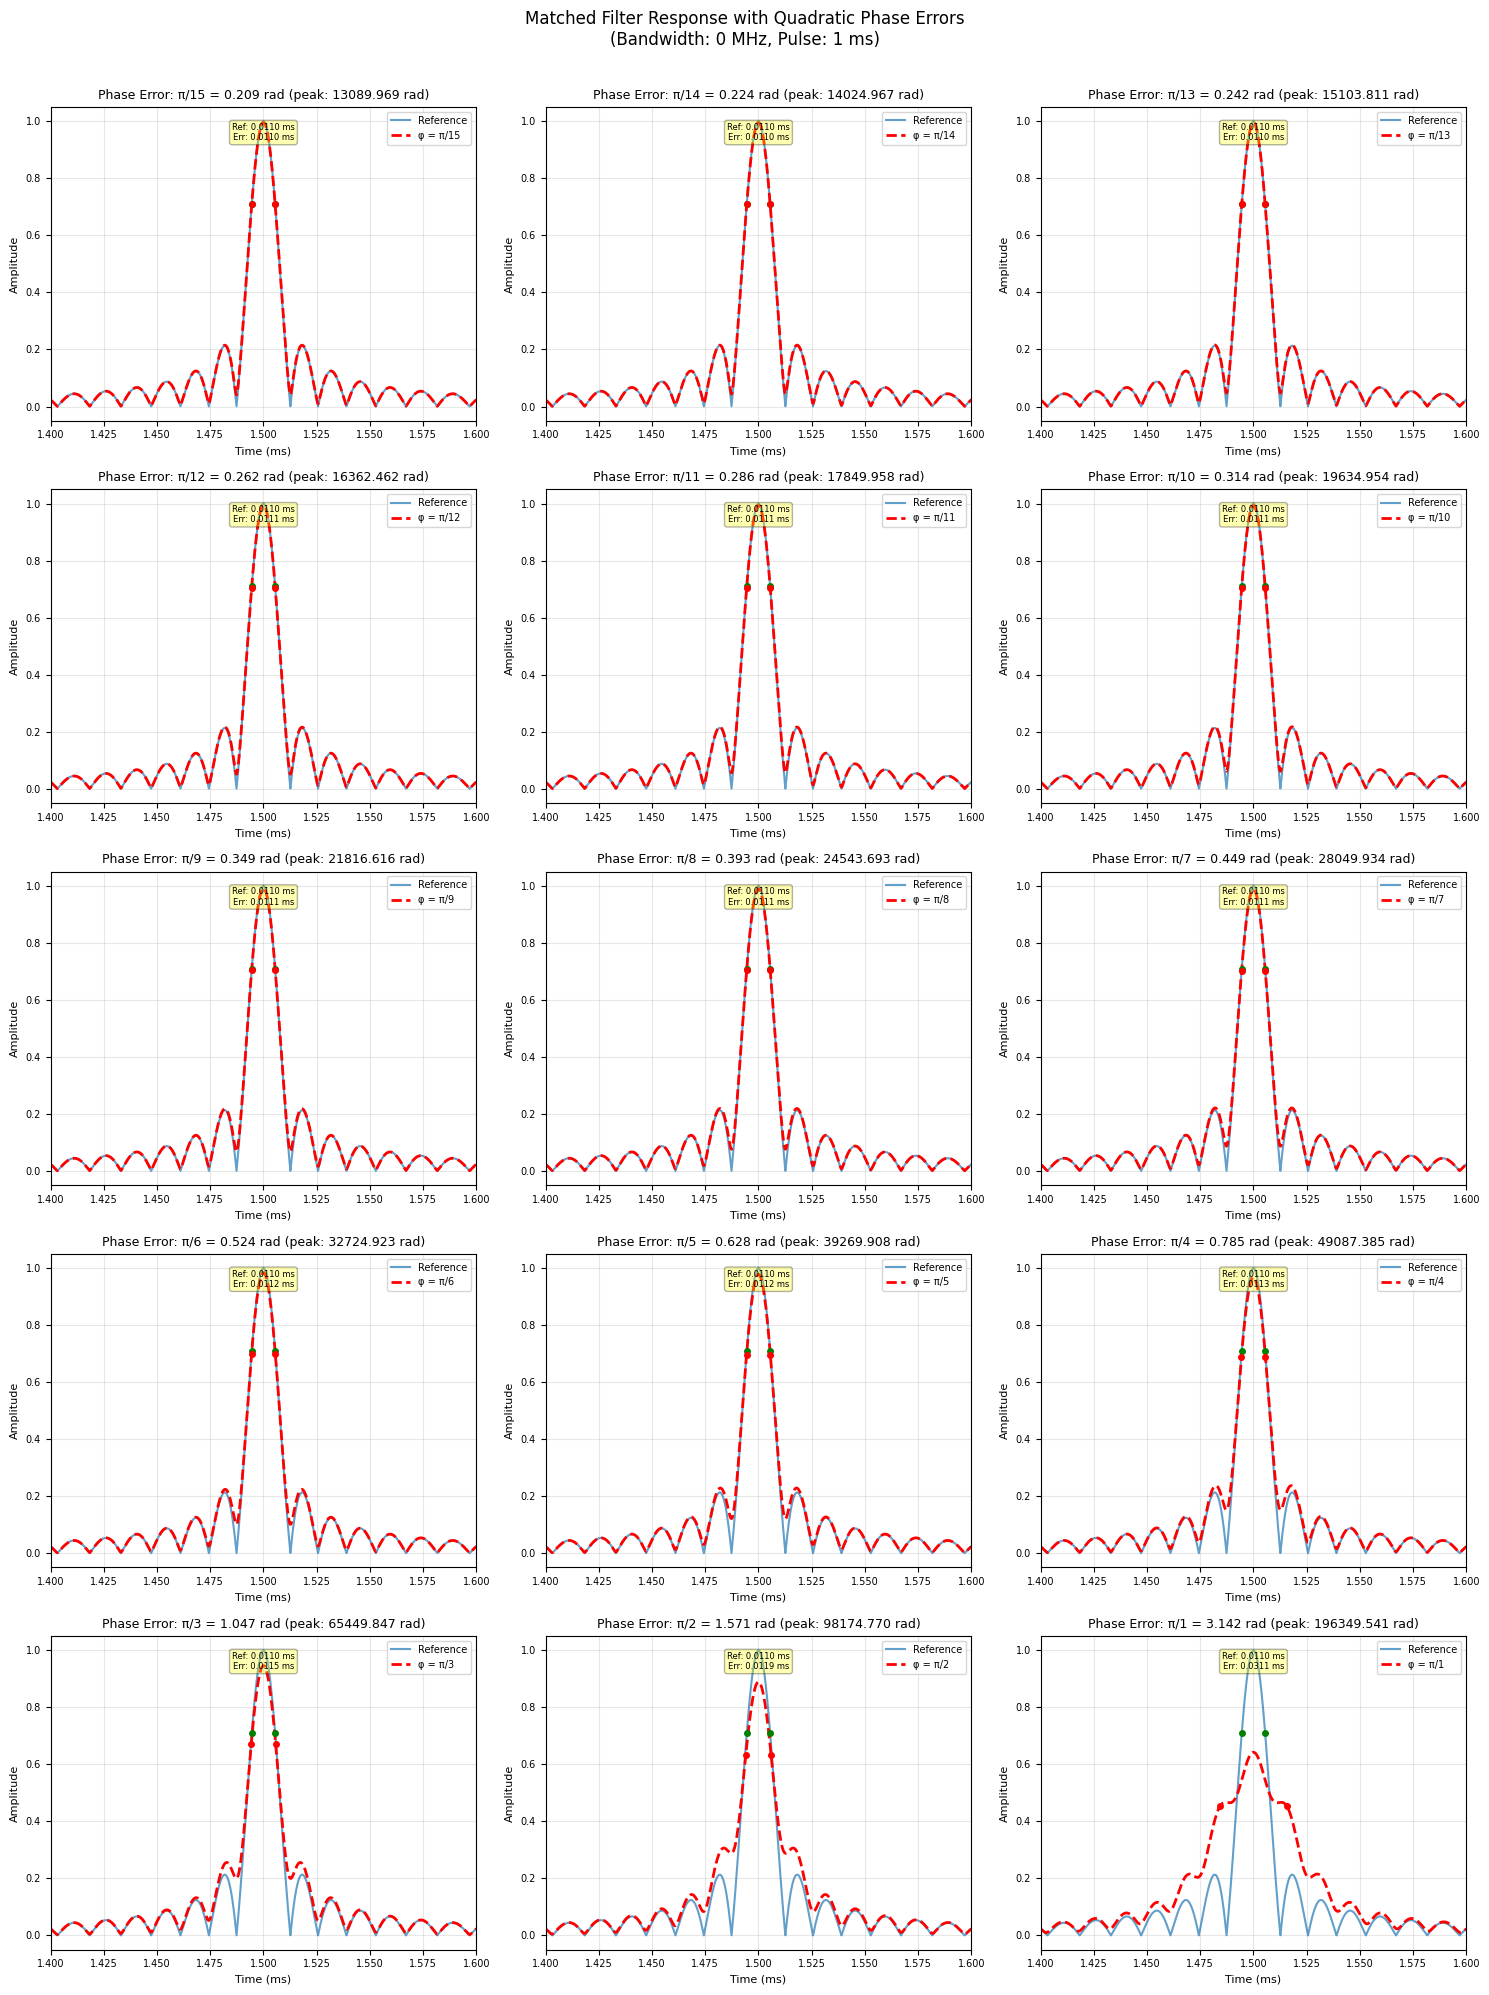

Signal bandwidth: 0.1 MHz
Maximum frequency: 0.0 MHz


In [95]:
 # Generate plots for phase errors: π/2, π/3, π/4, ..., π/16
phase_labels = [i for i in range(15,0,-1)]
phase_errors = [np.pi/n for n in phase_labels]

# Calculate bandwidth to determine appropriate coefficients
bandwidth = chirp_rate * pulse_width  # Hz
f_c = 0 # Centre frequency
f_max = f_c + bandwidth / 2

# Create figure with subplots
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()

for idx, (phase_err, n) in enumerate(zip(phase_errors, phase_labels)):
    # Calculate quad_coeff to achieve target phase error at f_max
    quad_coeff = phase_err / ((f_max-f_c)**2)
    
    # Frequency axis
    freq_axis_local = np.fft.fftshift(
        np.fft.fftfreq(len(time_axis), d=(time_axis[1] - time_axis[0]))
    )
    phi_quad = quad_coeff * ((freq_axis_local - f_c)**2)
    
    # Apply quadratic phase error
    chirp_signal_f_quad = np.fft.fftshift(np.fft.fft(chirp_signal_t))
    chirp_signal_f_quad *= np.exp(1j * phi_quad)
    
    # Matched filter outputs
    matched_filter_ref_f = chirp_signal_f * np.conj(chirp_signal_f)
    matched_filter_ref_t = np.fft.ifft(np.fft.ifftshift(matched_filter_ref_f))
    
    matched_filter_quad_f = chirp_signal_f_quad * np.conj(chirp_signal_f)
    matched_filter_quad_t = np.fft.ifft(np.fft.ifftshift(matched_filter_quad_f))
    
    # Calculate actual peak phase error achieved
    peak_phase = np.max(np.abs(phi_quad))
    
    # Plot matched filter impulse response
    ax = axes[idx]
    ref_shifted = np.fft.fftshift(np.abs(matched_filter_ref_t / max_mag))
    quad_shifted = np.fft.fftshift(np.abs(matched_filter_quad_t / max_mag))
    
    # Plot the signals
    ax.plot(time_axis * 1e3, ref_shifted, label='Reference', alpha=0.7, linewidth=1.5)
    ax.plot(time_axis * 1e3, quad_shifted, '--', 
            label=f'φ = π/{n}', linewidth=2, color='red')
    
    # Calculate 3dB points for reference signal
    ref_shifted_db = 20 * np.log10(ref_shifted / np.max(ref_shifted))
    threshold_3db = -3.0
    above_3db_ref = ref_shifted_db >= threshold_3db
    
    if np.any(above_3db_ref):
        indices_3db_ref = np.where(above_3db_ref)[0]
        if len(indices_3db_ref) > 1:
            idx_left_ref = indices_3db_ref[0]
            idx_right_ref = indices_3db_ref[-1]
            t_left_ref = time_axis[idx_left_ref] * 1e3
            t_right_ref = time_axis[idx_right_ref] * 1e3
            width_3db_ref = t_right_ref - t_left_ref
            
            # Mark 3dB points for reference
            ax.plot([t_left_ref, t_right_ref], 
                    [ref_shifted[idx_left_ref], ref_shifted[idx_right_ref]], 
                    'go', markersize=4)
    
    # Calculate 3dB points for phase error signal
    quad_shifted_db = 20 * np.log10(quad_shifted / np.max(quad_shifted))
    above_3db_quad = quad_shifted_db >= threshold_3db
    
    if np.any(above_3db_quad):
        indices_3db_quad = np.where(above_3db_quad)[0]
        if len(indices_3db_quad) > 1:
            idx_left_quad = indices_3db_quad[0]
            idx_right_quad = indices_3db_quad[-1]
            t_left_quad = time_axis[idx_left_quad] * 1e3
            t_right_quad = time_axis[idx_right_quad] * 1e3
            width_3db_quad = t_right_quad - t_left_quad
            
            # Mark 3dB points for phase error
            ax.plot([t_left_quad, t_right_quad], 
                    [quad_shifted[idx_left_quad], quad_shifted[idx_right_quad]], 
                    'ro', markersize=4)
            
            # Add 3dB width annotations
            if np.any(above_3db_ref) and len(indices_3db_ref) > 1:
                ax.annotate(f'Ref: {width_3db_ref:.4f} ms\nErr: {width_3db_quad:.4f} ms', 
                            xy=(0.5, 0.95), xycoords='axes fraction',
                            fontsize=6, ha='center', va='top',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            else:
                ax.annotate(f'Err: {width_3db_quad:.4f} ms', 
                            xy=(0.5, 0.95), xycoords='axes fraction',
                            fontsize=7, ha='center', va='top',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.set_xlim(1.4, 1.6)
    ax.set_title(f'Phase Error: π/{n} = {phase_err:.3f} rad (peak: {peak_phase:.3f} rad)', 
                fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle(f'Matched Filter Response with Quadratic Phase Errors\n' + 
            f'(Bandwidth: {bandwidth/1e6:.0f} MHz, Pulse: {pulse_width*1e3:.0f} ms)', 
            fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print(f"Signal bandwidth: {bandwidth/1e6:.1f} MHz")
print(f"Maximum frequency: {f_max/1e6:.1f} MHz")

pi/16, pi/8, ... pi/2 --> phase errors

Design buffer = 10% 
Find the difference between err and ref and the percentage diff. Make sure it is within the 10% design factor.

For example, if 3db of err is 0.0119 ms and the reference is 0.0110 ms, hence percentage widening is 8.18%. This means that I will use $\dfrac{\pi}{2}$ as my phase error tolerance.

The above plot allows me to understand the amount of broadening based on the amount of phase error. For example, if we were to want a 10% design factor, then we can choose $\dfrac{\pi}{2}$ as our peak-to-peak maximum phase error. 

When we later use polyfit to get the coefficients of the system's phase errors, we can plot each of the phase error degrees and check the peak-to-peak value. For example, if we get $ax^3 + bx^2 + cx + d$ from our polyfit. We will plot $bx^2$ in frequency and importantly the bandwidth we are interested in. The peak-to-peak value of this $bx^2$ plot should be within $\dfrac{\pi}{2}$ as defined by our design.

# Adding Cubic Phase Error


Here we add a phase term that is **cubic in frequency**:



$$\phi_{\text{cubic}}(f) = c\,(f - f_c)^3$$



and apply it by multiplying the complex baseband signal by



$$s_{\text{err}}(f) = s(f)\, e^{j\,\phi_{\text{cubic}}(f)}.$$



This mimics a cubic phase distortion pulse distortion, degraded matched-filter peaks, assymetric spectra.

Cubic phase error sidelobe metrics (relative to each curve mainlobe):


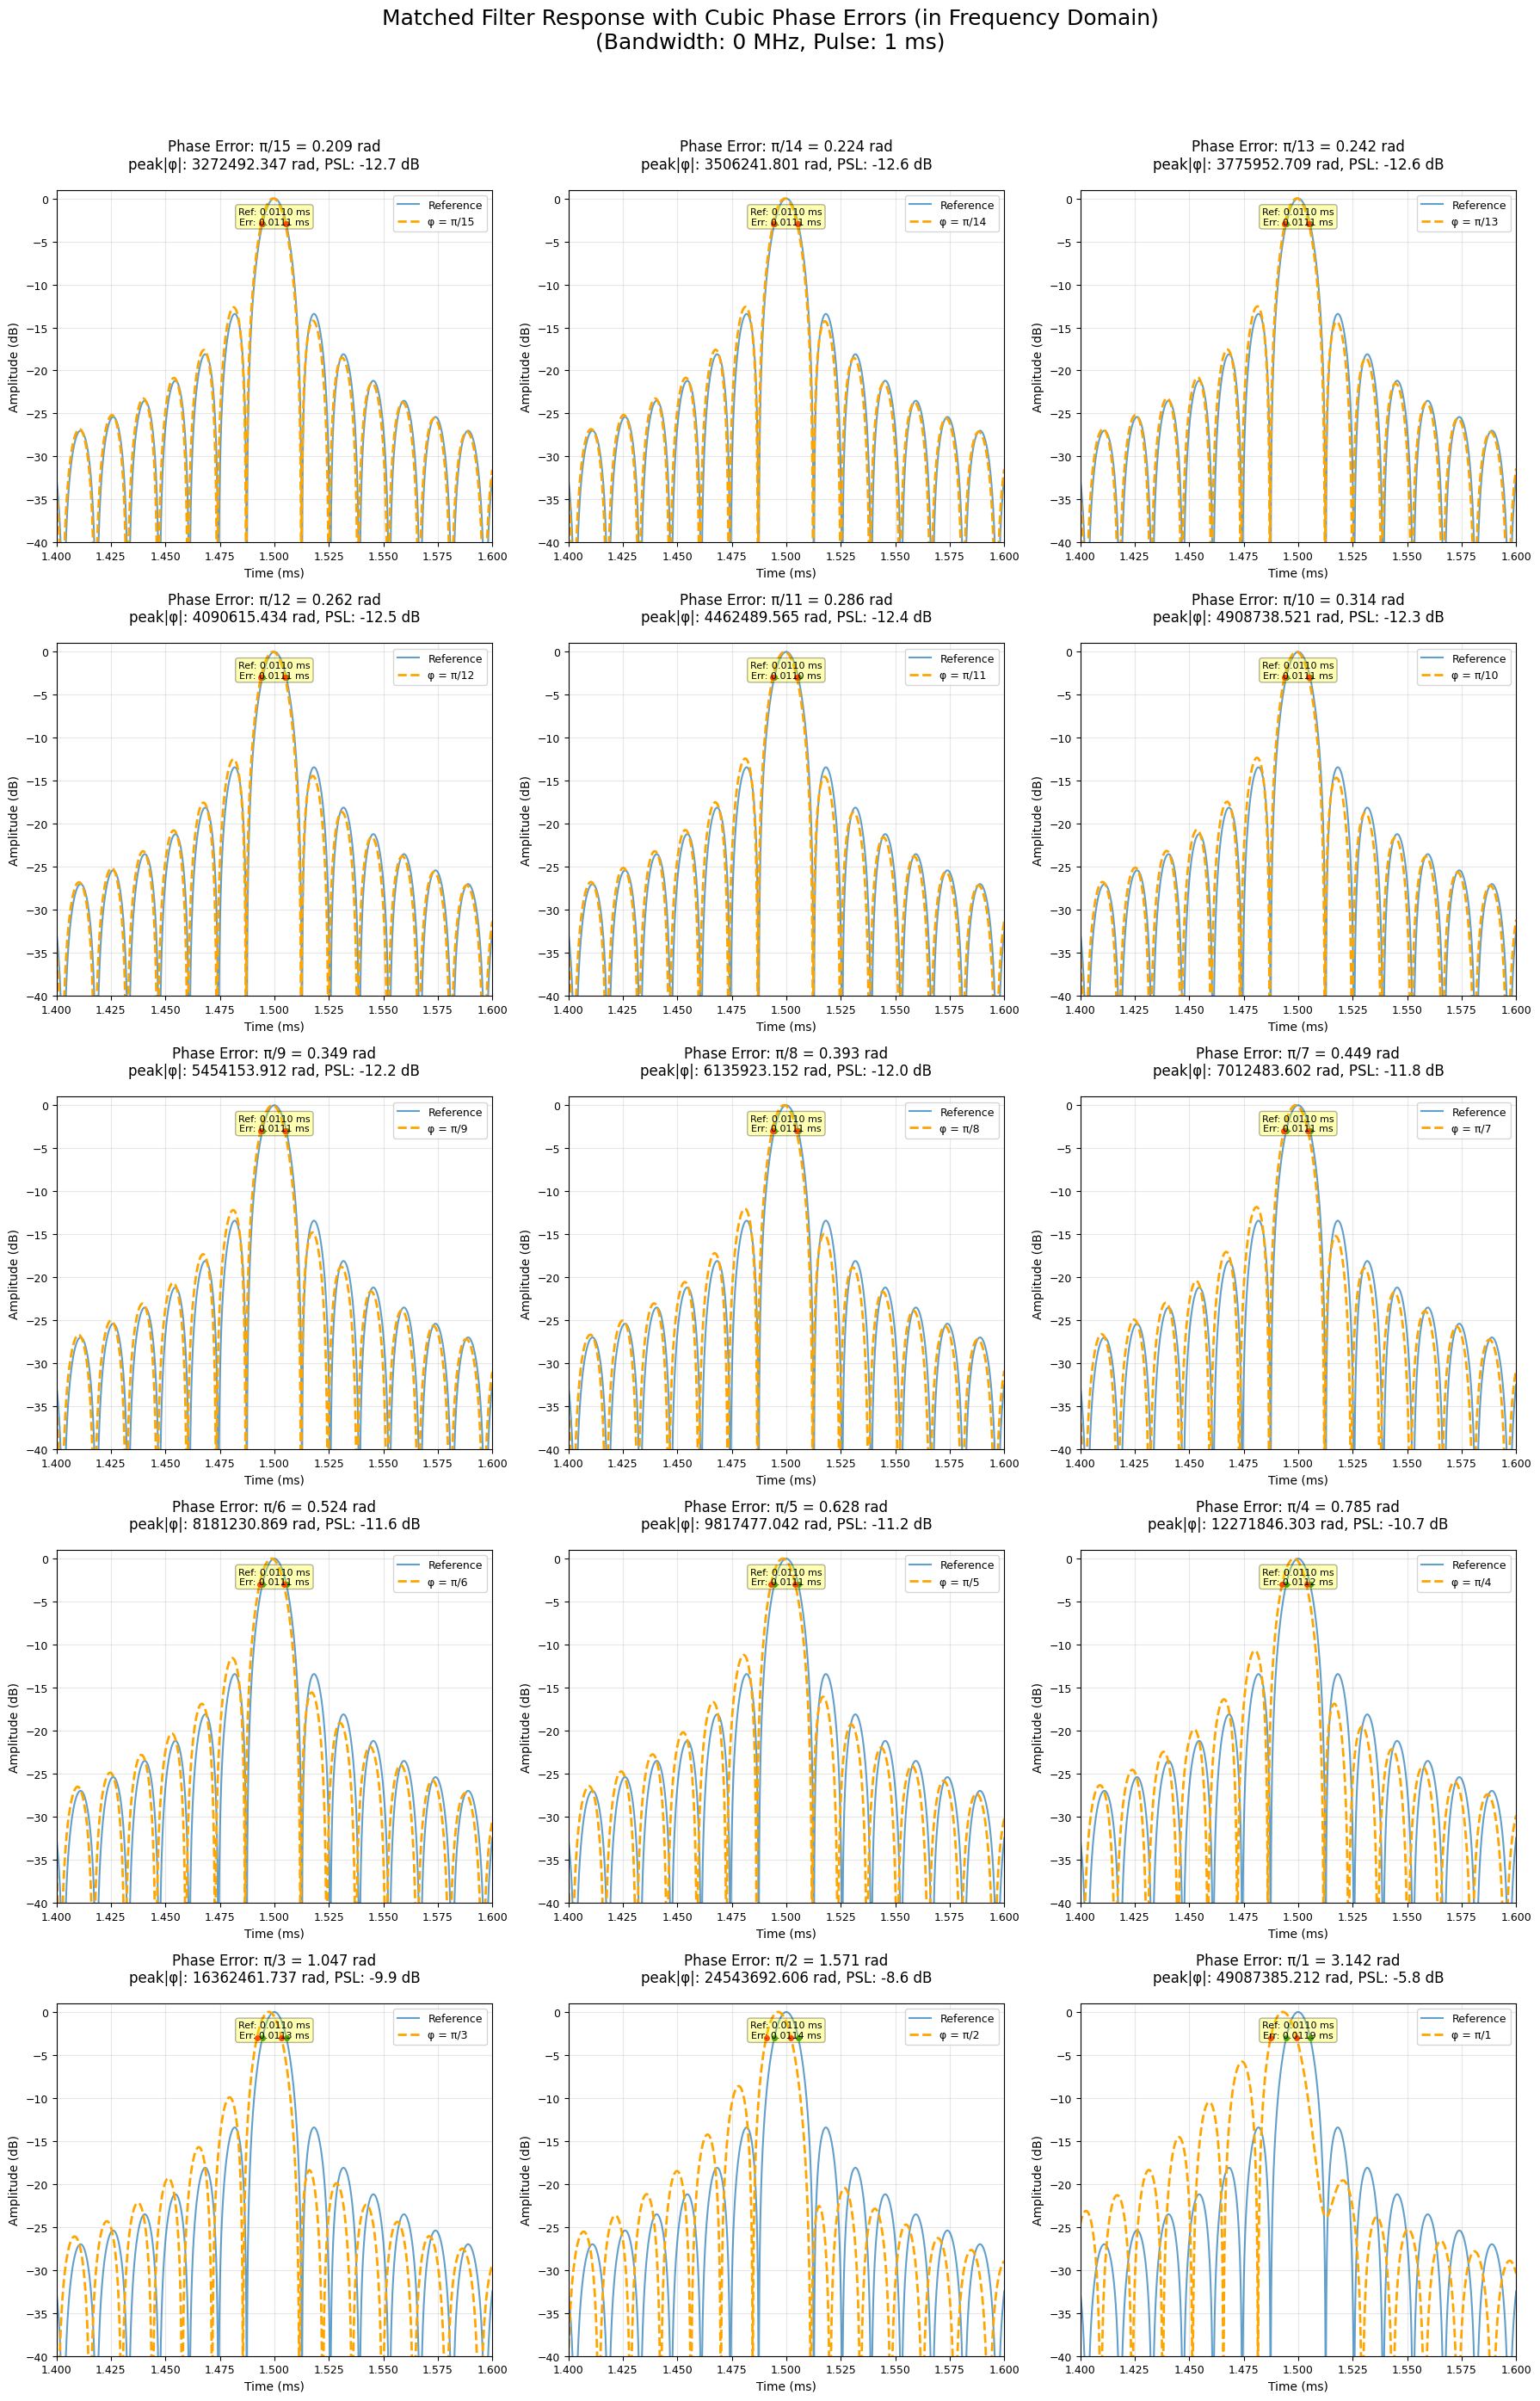

Pulse width: 1.0 ms
Maximum frequency deviation from center: 0.04 MHz


In [96]:
# Generate plots for phase errors: π/2, π/3, π/4, ..., π/16
phase_labels = [i for i in range(15,0,-1)]
phase_errors = [np.pi/n for n in phase_labels]

# For sidelobe metrics: size a small exclusion window around the mainlobe peak
bandwidth = chirp_rate * pulse_width  # Hz
mainlobe_exclusion_time = 2.0 / bandwidth  # seconds (roughly a few mainlobe widths)
half_excl_samp = int(np.ceil(mainlobe_exclusion_time * fs))
half_excl_samp = max(1, half_excl_samp)

# Centre frequency for phase calculation
f_c = 0  # or set to your actual center frequency if needed

print("Cubic phase error sidelobe metrics (relative to each curve mainlobe):")

# Create figure with subplots (larger, more vertical space)
fig, axes = plt.subplots(5, 3, figsize=(18, 28))
axes = axes.flatten()

for idx, (phase_err, n) in enumerate(zip(phase_errors, phase_labels)):
    # Calculate cubic_coeff to achieve target phase error at band edge
    cubic_coeff = phase_err / (f_max**3)

    # Cubic phase in frequency
    freq_axis_local = np.fft.fftshift(np.fft.fftfreq(len(time_axis), d=(time_axis[1] - time_axis[0])))
    phi_cubic_local = cubic_coeff * (freq_axis_local - f_c)**3

    # Apply cubic phase error in frequency domain
    chirp_signal_f_cubic = np.fft.fftshift(np.fft.fft(chirp_signal_t))
    chirp_signal_f_cubic *= np.exp(1j * phi_cubic_local)
    chirp_signal_t_cubic = np.fft.ifft(np.fft.ifftshift(chirp_signal_f_cubic))

    # Matched filter outputs
    matched_filter_ref_f = chirp_signal_f * np.conj(chirp_signal_f)
    matched_filter_ref_t = np.fft.ifft(np.fft.ifftshift(matched_filter_ref_f))

    matched_filter_cubic_f = chirp_signal_f_cubic * np.conj(chirp_signal_f)
    matched_filter_cubic_t = np.fft.ifft(np.fft.ifftshift(matched_filter_cubic_f))

    # Calculate actual peak phase error achieved
    peak_phase = np.max(np.abs(phi_cubic_local))

    # Plot matched filter impulse response
    ax = axes[idx]
    ref_shifted = np.fft.fftshift(np.abs(matched_filter_ref_t))
    cubic_shifted = np.fft.fftshift(np.abs(matched_filter_cubic_t))

    # --- PSL: next local maximum (peak) on either side of the mainlobe ---
    main_idx = int(np.argmax(cubic_shifted))
    peaks, _ = signal.find_peaks(cubic_shifted)
    # Find the closest peak to the mainlobe (excluding the mainlobe itself)
    if len(peaks) > 0:
        # Exclude the mainlobe peak if present in peaks
        peaks_wo_main = peaks[peaks != main_idx]
        if len(peaks_wo_main) > 0:
            closest_peak_idx = peaks_wo_main[np.argmin(np.abs(peaks_wo_main - main_idx))]
            next_peak = cubic_shifted[closest_peak_idx]
            psl_db = 20.0 * np.log10(next_peak / cubic_shifted[main_idx])
        else:
            psl_db = np.nan
    else:
        psl_db = np.nan

    # Plot the signals
    ax.plot(time_axis * 1e3, 20 * np.log10(ref_shifted / np.max(ref_shifted)), label='Reference', alpha=0.7, linewidth=1.5)
    ax.plot(time_axis * 1e3, 20 * np.log10(cubic_shifted / np.max(cubic_shifted)), '--', 
            label=f'φ = π/{n}', linewidth=2, color='orange')

    # Calculate 3dB points for reference signal
    ref_shifted_db = 20 * np.log10(ref_shifted / np.max(ref_shifted))
    threshold_3db = -3.0
    above_3db_ref = ref_shifted_db >= threshold_3db

    if np.any(above_3db_ref):
        indices_3db_ref = np.where(above_3db_ref)[0]
        if len(indices_3db_ref) > 1:
            idx_left_ref = indices_3db_ref[0]
            idx_right_ref = indices_3db_ref[-1]
            t_left_ref = time_axis[idx_left_ref] * 1e3
            t_right_ref = time_axis[idx_right_ref] * 1e3
            width_3db_ref = t_right_ref - t_left_ref

            # Mark 3dB points for reference
            ax.plot([t_left_ref, t_right_ref], 
                    [ref_shifted_db[idx_left_ref], ref_shifted_db[idx_right_ref]], 
                    'go', markersize=4)

    # Calculate 3dB points for phase error signal
    cubic_shifted_db = 20 * np.log10(cubic_shifted / np.max(cubic_shifted))
    above_3db_cubic = cubic_shifted_db >= threshold_3db

    if np.any(above_3db_cubic):
        indices_3db_cubic = np.where(above_3db_cubic)[0]
        if len(indices_3db_cubic) > 1:
            idx_left_cubic = indices_3db_cubic[0]
            idx_right_cubic = indices_3db_cubic[-1]
            t_left_cubic = time_axis[idx_left_cubic] * 1e3
            t_right_cubic = time_axis[idx_right_cubic] * 1e3
            width_3db_cubic = t_right_cubic - t_left_cubic

            # Mark 3dB points for phase error
            ax.plot([t_left_cubic, t_right_cubic], 
                    [cubic_shifted_db[idx_left_cubic], cubic_shifted_db[idx_right_cubic]], 
                    'ro', markersize=4)

            # Add 3dB width annotations
            if np.any(above_3db_ref) and len(indices_3db_ref) > 1:
                ax.annotate(f'Ref: {width_3db_ref:.4f} ms\nErr: {width_3db_cubic:.4f} ms', 
                            xy=(0.5, 0.95), xycoords='axes fraction',
                            fontsize=8, ha='center', va='top',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            else:
                ax.annotate(f'Err: {width_3db_cubic:.4f} ms', 
                            xy=(0.5, 0.95), xycoords='axes fraction',
                            fontsize=8, ha='center', va='top',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

    ax.set_xlabel('Time (ms)', fontsize=10)
    ax.set_ylabel('Amplitude (dB)', fontsize=10)
    ax.set_xlim(1.4, 1.6)
    ax.set_ylim(-40, 1)
    ax.set_title(
        f'Phase Error: π/{n} = {phase_err:.3f} rad\npeak|φ|: {peak_phase:.3f} rad, PSL: {psl_db:.1f} dB',
        fontsize=12,
        pad=18,
    )
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.suptitle(f'Matched Filter Response with Cubic Phase Errors (in Frequency Domain)\n' + 
                f'(Bandwidth: {bandwidth/1e6:.0f} MHz, Pulse: {pulse_width*1e3:.0f} ms)', 
                fontsize=18, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print(f"Pulse width: {pulse_width*1e3:.1f} ms")
print(f"Maximum frequency deviation from center: {f_max/1e6:.2f} MHz")

sidelobe after taylor weighting is -35dB

phase_errors: 15
phase_labels: 15
chirp_signal_t len: 60000
time_axis len: 60000
lines_plotted: 30


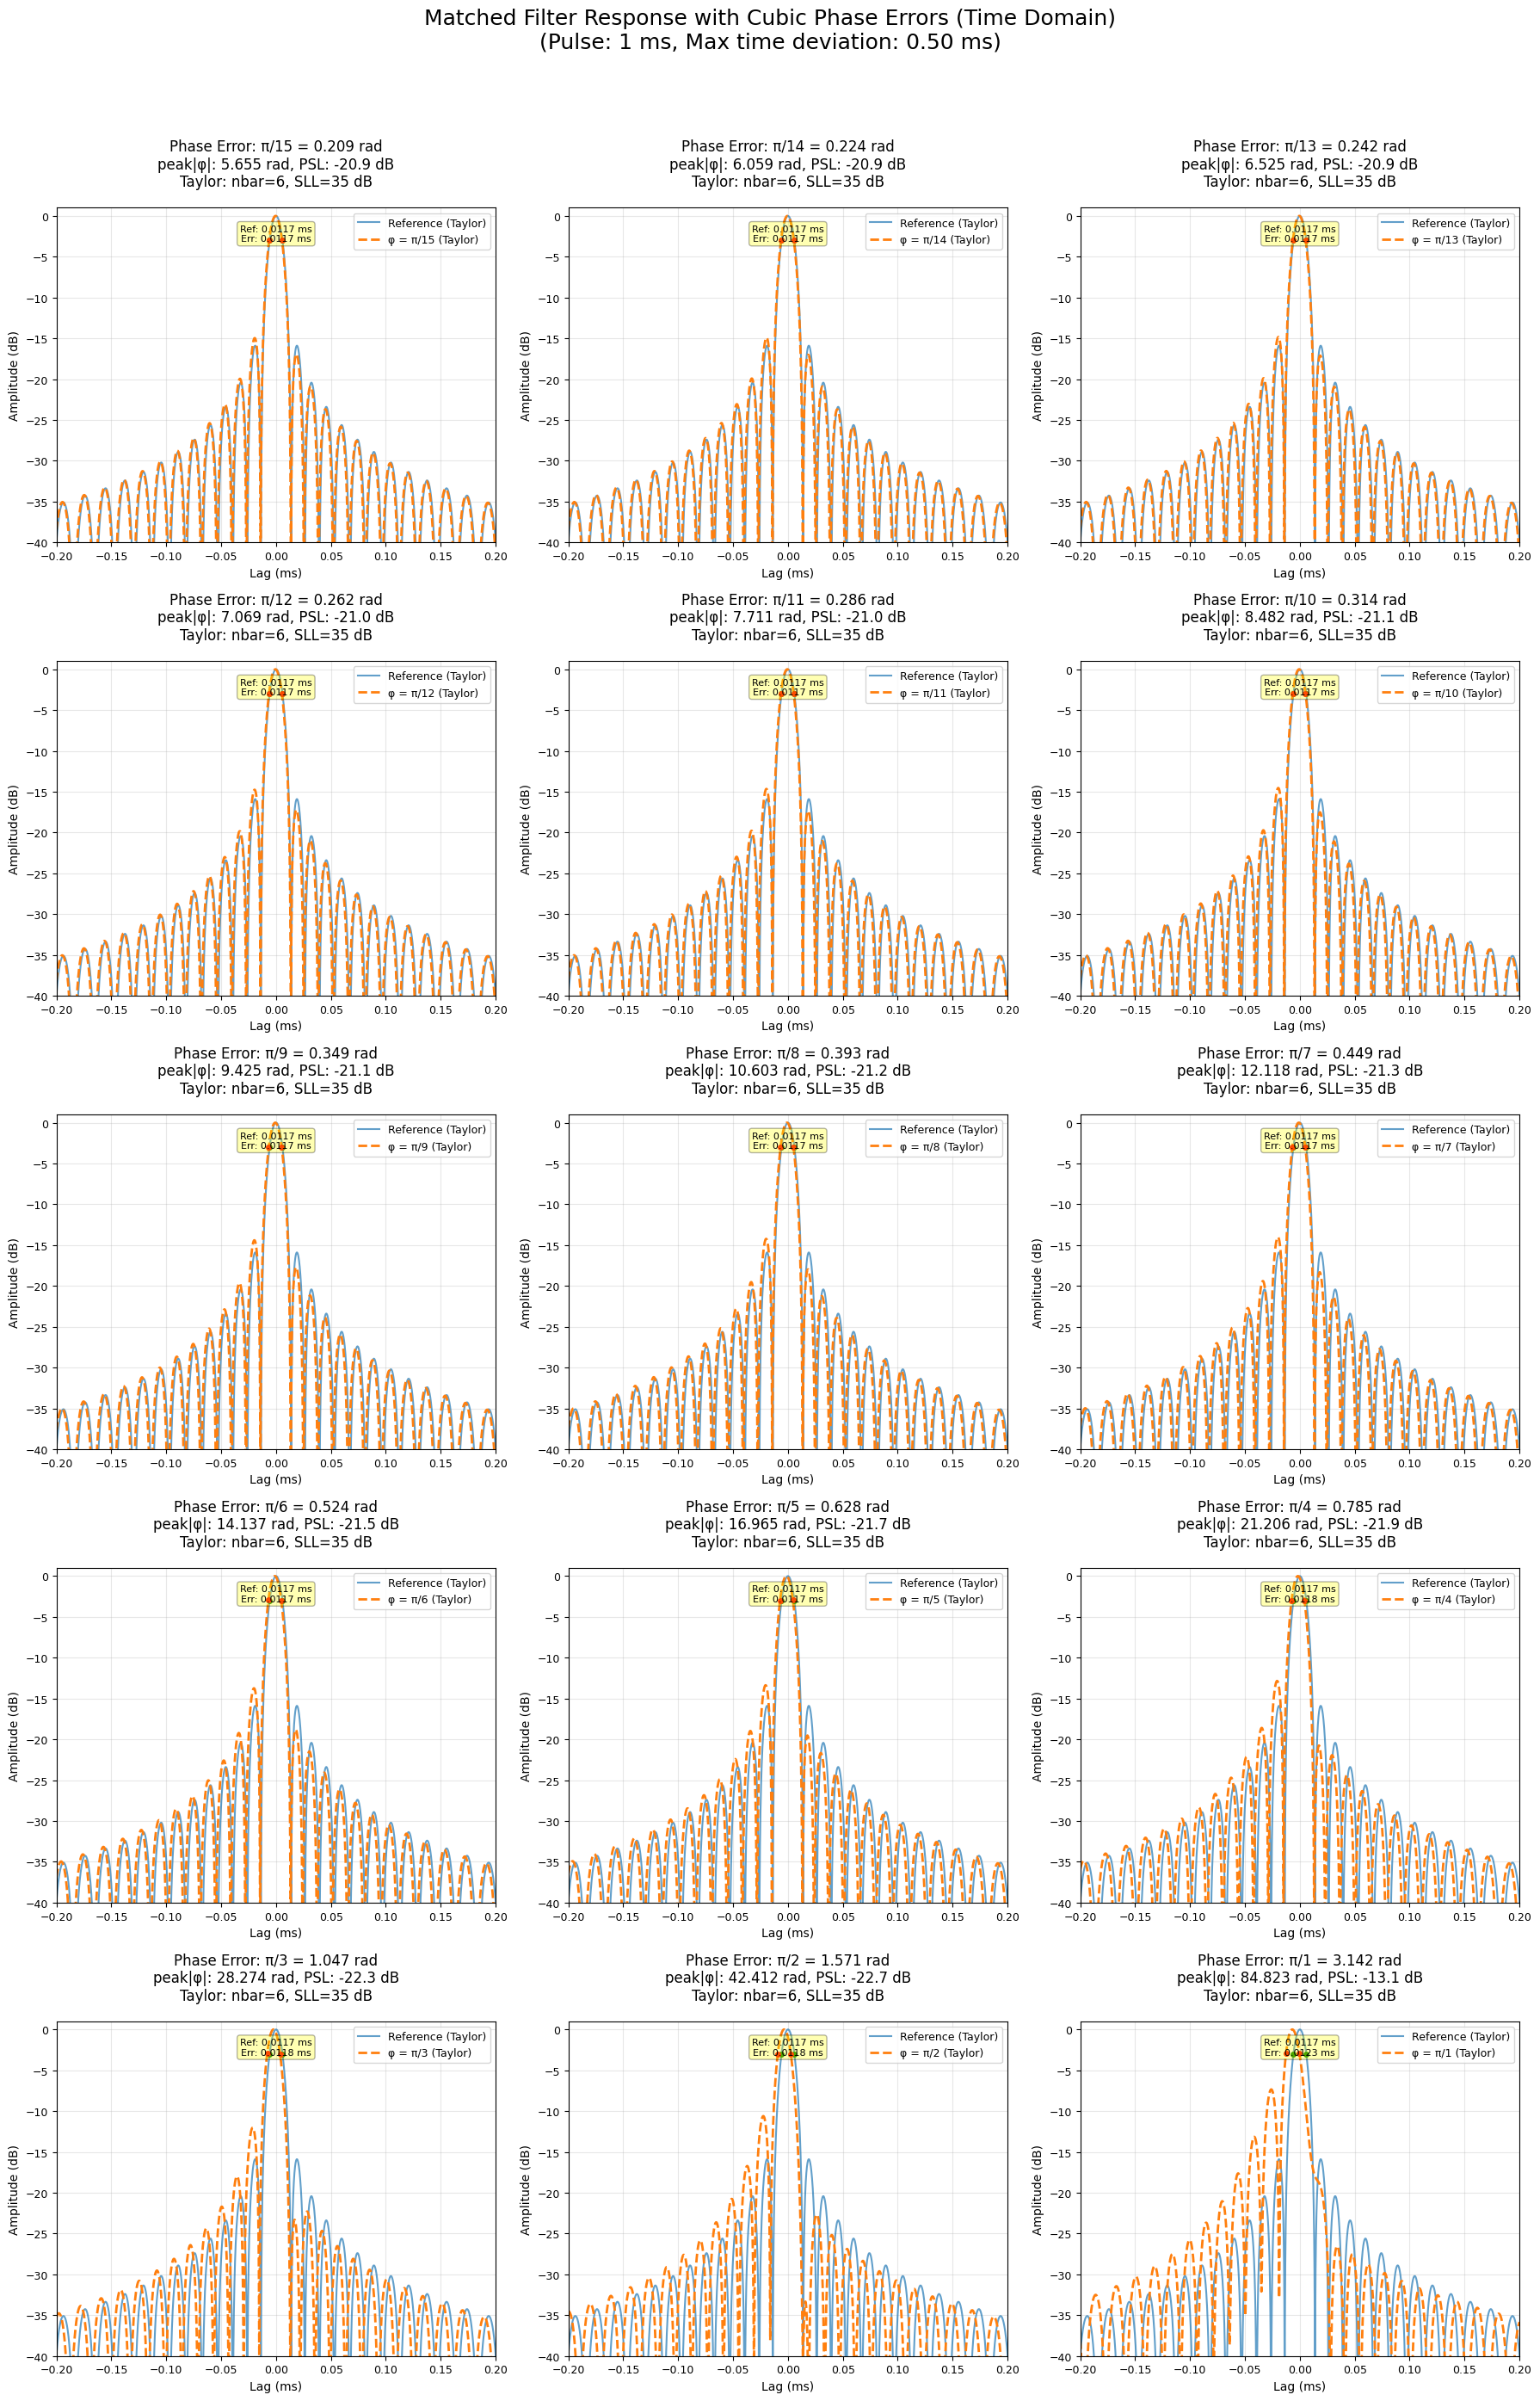

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal.windows import taylor

# -------------------------
# Sanity checks (prints)
# -------------------------
print("phase_errors:", len(phase_errors))
print("phase_labels:", len(phase_labels))
print("chirp_signal_t len:", len(chirp_signal_t))
print("time_axis len:", len(time_axis))

# -------------------------
# Create figure and axes here (avoid stale axes)
# -------------------------
fig, axes = plt.subplots(5, 3, figsize=(18, 28))
axes = axes.flatten()

# -------------------------
# Taylor window settings
# -------------------------
taylor_nbar = 6
taylor_sll_db = 35
taylor_norm = False

db_floor = -80.0
eps = 10.0 ** (db_floor / 20.0)

w_taylor = taylor(
    M=len(chirp_signal_t),
    nbar=taylor_nbar,
    sll=taylor_sll_db,
    norm=taylor_norm
)

# Windowed reference chirp and reference matched filter output
chirp_signal_t_win = chirp_signal_t * w_taylor
chirp_signal_f_win = np.fft.fftshift(np.fft.fft(chirp_signal_t_win))

matched_filter_ref_f_win = chirp_signal_f_win * np.conj(chirp_signal_f_win)
matched_filter_ref_t_win = np.fft.ifft(np.fft.ifftshift(matched_filter_ref_f_win))

# Correct x axis for matched filter impulse response after fftshift (lag axis)
N = len(chirp_signal_t)
lag_time_ms = ((np.arange(N) - (N // 2)) / fs) * 1e3

lines_plotted = 0

for idx, (phase_err, n) in enumerate(zip(phase_errors, phase_labels)):
    ax = axes[idx]

    cubic_coeff = phase_err / (t_max**3)
    phi_cubic_local = cubic_coeff * (time_axis - t_c_local)**3

    chirp_signal_t_cubic = chirp_signal_t * np.exp(1j * phi_cubic_local)
    chirp_signal_t_cubic_win = chirp_signal_t_cubic * w_taylor

    chirp_signal_f_cubic_win = np.fft.fftshift(np.fft.fft(chirp_signal_t_cubic_win))

    matched_filter_cubic_f_win = chirp_signal_f_cubic_win * np.conj(chirp_signal_f_win)
    matched_filter_cubic_t_win = np.fft.ifft(np.fft.ifftshift(matched_filter_cubic_f_win))

    ref_shifted = np.fft.fftshift(np.abs(matched_filter_ref_t_win))
    cubic_shifted = np.fft.fftshift(np.abs(matched_filter_cubic_t_win))

    peak_phase = np.max(np.abs(phi_cubic_local))

    ref_norm = ref_shifted / np.max(ref_shifted)
    cubic_norm = cubic_shifted / np.max(cubic_shifted)

    ref_db = 20.0 * np.log10(np.maximum(ref_norm, eps))
    cubic_db = 20.0 * np.log10(np.maximum(cubic_norm, eps))

    ax.plot(lag_time_ms, ref_db, label="Reference (Taylor)", alpha=0.7, linewidth=1.5)
    ax.plot(lag_time_ms, cubic_db, linestyle="--", label=f"φ = π/{n} (Taylor)", linewidth=2)

    lines_plotted += 2

    main_idx = int(np.argmax(cubic_shifted))
    peaks, _ = signal.find_peaks(cubic_shifted)

    if len(peaks) > 0:
        peaks_wo_main = peaks[peaks != main_idx]
        if "half_excl_samp" in globals():
            peaks_wo_main = peaks_wo_main[np.abs(peaks_wo_main - main_idx) > half_excl_samp]
        if len(peaks_wo_main) > 0:
            closest_peak_idx = peaks_wo_main[np.argmin(np.abs(peaks_wo_main - main_idx))]
            next_peak = cubic_shifted[closest_peak_idx]
            psl_db = 20.0 * np.log10(next_peak / cubic_shifted[main_idx])
        else:
            psl_db = np.nan
    else:
        psl_db = np.nan

    threshold_3db = -3.0
    above_3db_ref = ref_db >= threshold_3db
    above_3db_cubic = cubic_db >= threshold_3db

    width_3db_ref = np.nan
    width_3db_cubic = np.nan

    if np.any(above_3db_ref):
        idxs = np.where(above_3db_ref)[0]
        if len(idxs) > 1:
            l = idxs[0]
            r = idxs[-1]
            width_3db_ref = lag_time_ms[r] - lag_time_ms[l]
            ax.plot([lag_time_ms[l], lag_time_ms[r]], [ref_db[l], ref_db[r]], "go", markersize=4)

    if np.any(above_3db_cubic):
        idxs = np.where(above_3db_cubic)[0]
        if len(idxs) > 1:
            l = idxs[0]
            r = idxs[-1]
            width_3db_cubic = lag_time_ms[r] - lag_time_ms[l]
            ax.plot([lag_time_ms[l], lag_time_ms[r]], [cubic_db[l], cubic_db[r]], "ro", markersize=4)

    if np.isfinite(width_3db_cubic):
        if np.isfinite(width_3db_ref):
            ax.text(
                0.5, 0.95,
                f"Ref: {width_3db_ref:.4f} ms\nErr: {width_3db_cubic:.4f} ms",
                transform=ax.transAxes,
                ha="center", va="top",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3)
            )
        else:
            ax.text(
                0.5, 0.95,
                f"Err: {width_3db_cubic:.4f} ms",
                transform=ax.transAxes,
                ha="center", va="top",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3)
            )

    ax.set_xlabel("Lag (ms)", fontsize=10)
    ax.set_ylabel("Amplitude (dB)", fontsize=10)

    ax.set_xlim(-0.2, 0.2)
    ax.set_ylim(-40, 1)

    ax.set_title(
        f"Phase Error: π/{n} = {phase_err:.3f} rad\n"
        f"peak|φ|: {peak_phase:.3f} rad, PSL: {psl_db:.1f} dB\n"
        f"Taylor: nbar={taylor_nbar}, SLL={taylor_sll_db} dB",
        fontsize=12,
        pad=18
    )
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

print("lines_plotted:", lines_plotted)

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.suptitle(
    f"Matched Filter Response with Cubic Phase Errors (Time Domain)\n"
    f"(Pulse: {pulse_width*1e3:.0f} ms, Max time deviation: {t_max*1e3:.2f} ms)",
    fontsize=18, y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.draw()
plt.show(block=True)


# Adding Quartic Phase Error




Here we add a phase term that is **quartic in frequency**:





$$\phi_{\text{quartic}}(f) = d\,(f - f_c)^4$$





and apply it by multiplying the complex baseband signal by





$$s_{\text{err}}(f) = s(f)\, e^{j\,\phi_{\text{quartic}}(f)}.$$




This mimics a higher-order phase distortion beyond cubic (strong nonlinear dispersion), leading to pulse distortion, degraded matched-filter peaks, and asymmetric spectra.

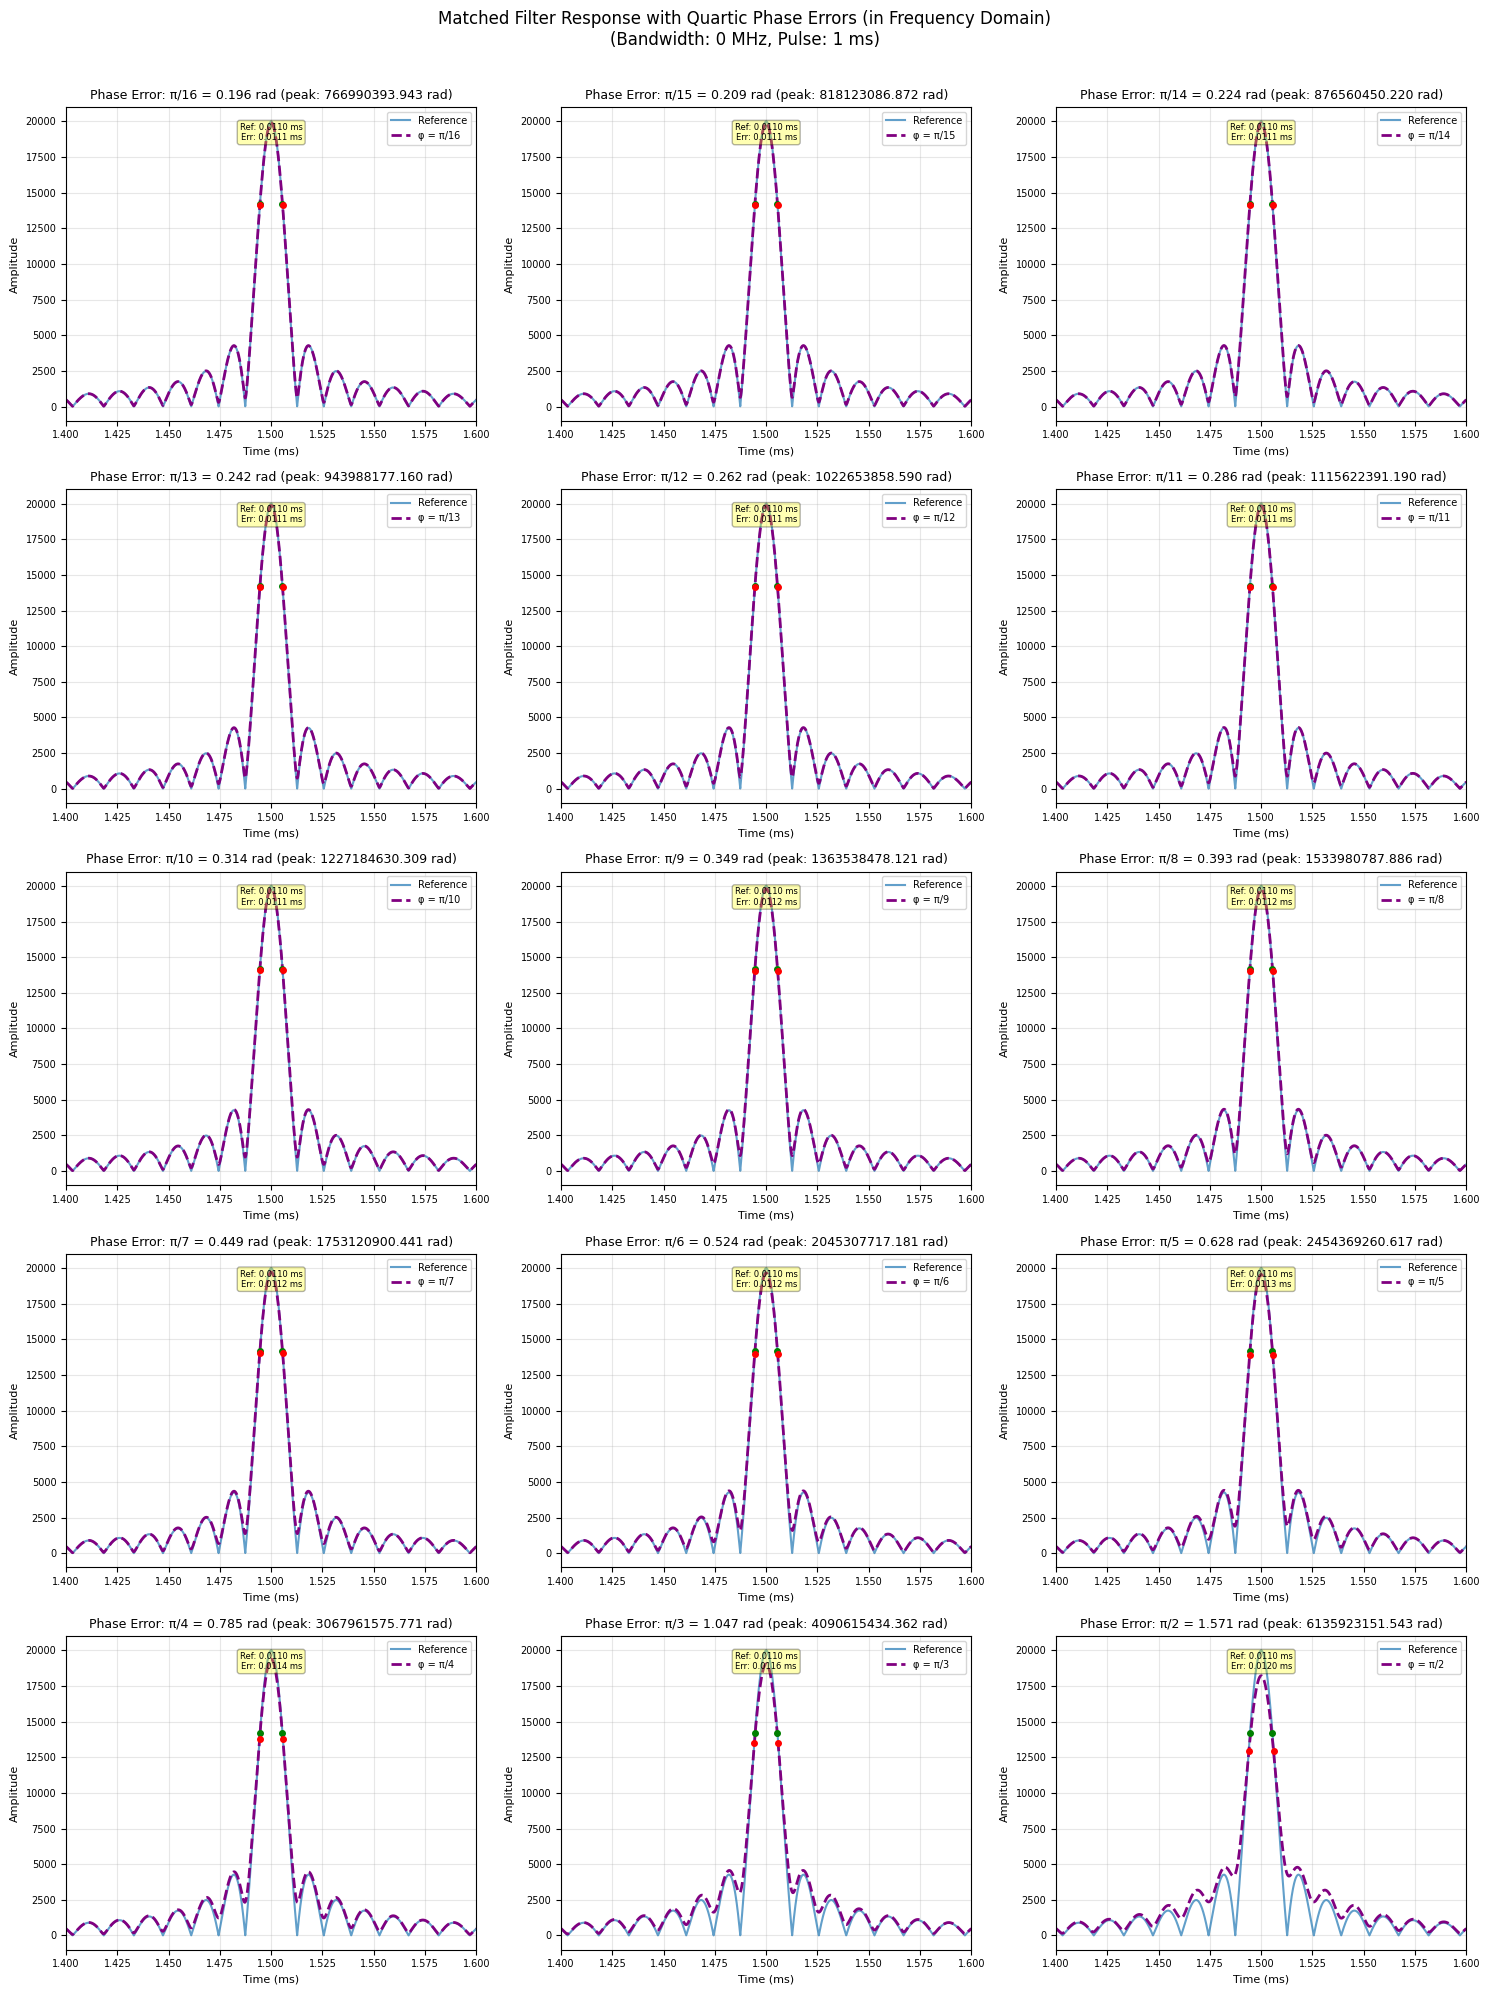

Signal bandwidth: 0.1 MHz
Maximum frequency: 0.0 MHz


In [6]:
# Generate plots for phase errors: π/2, π/3, π/4, ..., π/16
phase_labels = [i for i in range(16,1,-1)]
phase_errors = [np.pi/n for n in phase_labels]

# Calculate bandwidth to determine appropriate coefficients
bandwidth = chirp_rate * pulse_width  # Hz
f_max = bandwidth / 2
f_c = 0  # Centre frequency

# Create figure with subplots
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()

for idx, (phase_err, n) in enumerate(zip(phase_errors, phase_labels)):
    # Calculate quartic_coeff to achieve target phase error at f_max
    quartic_coeff = phase_err / (f_max**4)
    
    # Frequency axis
    freq_axis_local = np.fft.fftshift(
        np.fft.fftfreq(len(time_axis), d=(time_axis[1] - time_axis[0]))
    )
    phi_quartic_local = quartic_coeff * (freq_axis_local - f_c)**4
    
    # Apply quartic phase error in frequency domain
    chirp_signal_f_quartic = np.fft.fftshift(np.fft.fft(chirp_signal_t))
    chirp_signal_f_quartic *= np.exp(1j * phi_quartic_local)
    
    # Matched filter outputs
    matched_filter_ref_f = chirp_signal_f * np.conj(chirp_signal_f)
    matched_filter_ref_t = np.fft.ifft(np.fft.ifftshift(matched_filter_ref_f))
    
    matched_filter_quartic_f = chirp_signal_f_quartic * np.conj(chirp_signal_f)
    matched_filter_quartic_t = np.fft.ifft(np.fft.ifftshift(matched_filter_quartic_f))
    
    # Calculate actual peak phase error achieved
    peak_phase = np.max(np.abs(phi_quartic_local))
    
    # Plot matched filter impulse response
    ax = axes[idx]
    ref_shifted = np.fft.fftshift(np.abs(matched_filter_ref_t))
    quartic_shifted = np.fft.fftshift(np.abs(matched_filter_quartic_t))
    
    # Plot the signals
    ax.plot(time_axis * 1e3, ref_shifted, label='Reference', alpha=0.7, linewidth=1.5)
    ax.plot(time_axis * 1e3, quartic_shifted, '--', 
            label=f'φ = π/{n}', linewidth=2, color='purple')
    
    # Calculate 3dB points for reference signal
    ref_shifted_db = 20 * np.log10(ref_shifted / np.max(ref_shifted))
    threshold_3db = -3.0
    above_3db_ref = ref_shifted_db >= threshold_3db
    
    if np.any(above_3db_ref):
        indices_3db_ref = np.where(above_3db_ref)[0]
        if len(indices_3db_ref) > 1:
            idx_left_ref = indices_3db_ref[0]
            idx_right_ref = indices_3db_ref[-1]
            t_left_ref = time_axis[idx_left_ref] * 1e3
            t_right_ref = time_axis[idx_right_ref] * 1e3
            width_3db_ref = t_right_ref - t_left_ref
            
            # Mark 3dB points for reference
            ax.plot([t_left_ref, t_right_ref], 
                    [ref_shifted[idx_left_ref], ref_shifted[idx_right_ref]], 
                    'go', markersize=4)
    
    # Calculate 3dB points for phase error signal
    quartic_shifted_db = 20 * np.log10(quartic_shifted / np.max(quartic_shifted))
    above_3db_quartic = quartic_shifted_db >= threshold_3db
    
    if np.any(above_3db_quartic):
        indices_3db_quartic = np.where(above_3db_quartic)[0]
        if len(indices_3db_quartic) > 1:
            idx_left_quartic = indices_3db_quartic[0]
            idx_right_quartic = indices_3db_quartic[-1]
            t_left_quartic = time_axis[idx_left_quartic] * 1e3
            t_right_quartic = time_axis[idx_right_quartic] * 1e3
            width_3db_quartic = t_right_quartic - t_left_quartic
            
            # Mark 3dB points for phase error
            ax.plot([t_left_quartic, t_right_quartic], 
                    [quartic_shifted[idx_left_quartic], quartic_shifted[idx_right_quartic]], 
                    'ro', markersize=4)
            
            # Add 3dB width annotations
            if np.any(above_3db_ref) and len(indices_3db_ref) > 1:
                ax.annotate(f'Ref: {width_3db_ref:.4f} ms\nErr: {width_3db_quartic:.4f} ms', 
                            xy=(0.5, 0.95), xycoords='axes fraction',
                            fontsize=6, ha='center', va='top',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            else:
                ax.annotate(f'Err: {width_3db_quartic:.4f} ms', 
                            xy=(0.5, 0.95), xycoords='axes fraction',
                            fontsize=7, ha='center', va='top',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.set_xlim(1.4, 1.6)
    ax.set_title(f'Phase Error: π/{n} = {phase_err:.3f} rad (peak: {peak_phase:.3f} rad)', 
                    fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle(f'Matched Filter Response with Quartic Phase Errors (in Frequency Domain)\n' + 
            f'(Bandwidth: {bandwidth/1e6:.0f} MHz, Pulse: {pulse_width*1e3:.0f} ms)', 
            fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print(f"Signal bandwidth: {bandwidth/1e6:.1f} MHz")
print(f"Maximum frequency: {f_max/1e6:.1f} MHz")

## Example System Coefficient
Here, we illustrate using a cascaded system and its coefficients to check if system is within design tolerance.

We will use this obtained parameters:
$$
3.117749 * 10^{-24} f^3 - 5.379796 * 10^{-16} f^2 + 2.589 * 10^{-8} f + 2.614046
$$

Plotting for quadratic, where we want the peak-to-peak design tolerance to be within $\dfrac{\pi}{2}$

In [22]:
start_hz = 1e7
stop_hz = 1e8
BW = stop_hz - start_hz
center_hz = (start_hz + stop_hz) / 2
quadratic_coeff = -5.379796e-16

quad_val = quadratic_coeff * (freq_axis)**2

Quadratic coeff d = -5.379796e-16 rad/Hz^2
Quadratic phase peak-to-peak over band = 1.089409 rad
Quadratic phase peak |phi| over band     = 1.089409 rad
Design check (p2p <= π/2): True


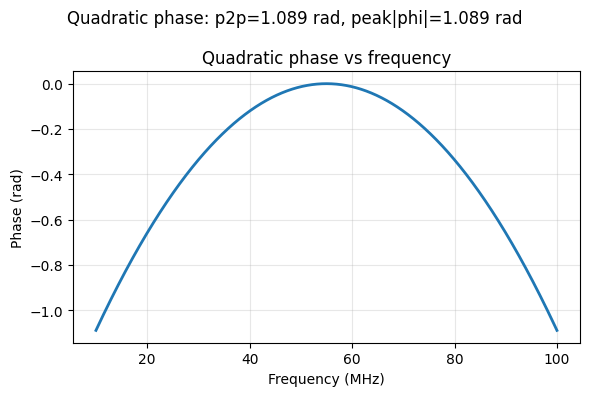

In [27]:
# Frequency grid across the band of interest
n_points = 20001
freq_hz = np.linspace(start_hz, stop_hz, n_points)
df_hz = freq_hz - center_hz  # offset from f_c

phi_quad_rad = quadratic_coeff * (df_hz ** 2)

phi_p2p = np.ptp(phi_quad_rad)                 # max - min across band
phi_peak_abs = np.max(np.abs(phi_quad_rad))    # max |phi| across band

print(f"Quadratic coeff d = {quadratic_coeff:.6e} rad/Hz^2")
print(f"Quadratic phase peak-to-peak over band = {phi_p2p:.6f} rad")
print(f"Quadratic phase peak |phi| over band     = {phi_peak_abs:.6f} rad")
print(f"Design check (p2p <= π/2): {phi_p2p <= (np.pi/2)}")

# Plot only vs absolute frequency (MHz)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(freq_hz / 1e6, phi_quad_rad, linewidth=2)
ax.set_title("Quadratic phase vs frequency")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Phase (rad)")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Quadratic phase: p2p={phi_p2p:.3f} rad, peak|phi|={phi_peak_abs:.3f} rad")
plt.tight_layout()
plt.show()

Now for cubic phase error, we want $\dfrac{\pi}{8}$ as our phase limit.

Cubic coeff c = 3.117749e-24 rad/Hz^3
Cubic phase peak-to-peak over band = 0.568210 rad
Cubic phase peak |phi| over band     = 0.284105 rad
Design check (p2p <= π/8): False


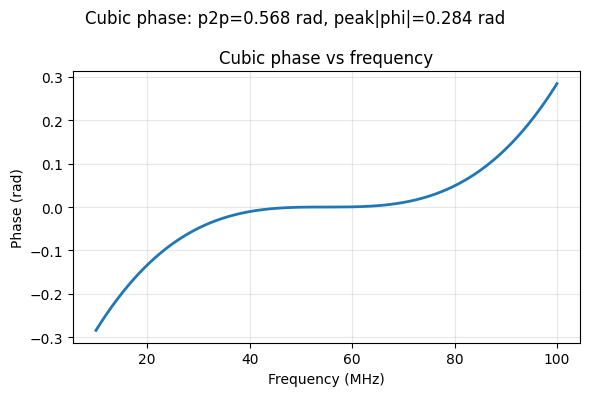

In [ ]:
# Cubic phase check for example system coefficient
cubic_coeff = 3.117749e-24  # rad/Hz^3 (from: 3.117749 * 10^-24 f^3)

# Frequency grid across the band of interest
n_points = 20001
freq_hz = np.linspace(start_hz, stop_hz, n_points)
df_hz = freq_hz - center_hz  # offset from f_c (consistent with prior quadratic check)

# Phase contribution from the cubic term
phi_cubic_rad = cubic_coeff * (df_hz ** 3)

phi_cubic_p2p = np.ptp(phi_cubic_rad)              # max - min across band
phi_cubic_peak_abs = np.max(np.abs(phi_cubic_rad)) # max |phi| across band
tol = np.pi / 8

print(f"Cubic coeff c = {cubic_coeff:.6e} rad/Hz^3")
print(f"Cubic phase peak-to-peak over band = {phi_cubic_p2p:.6f} rad")
print(f"Cubic phase peak |phi| over band     = {phi_cubic_peak_abs:.6f} rad")
print(f"Design check (p2p <= π/8): {phi_cubic_p2p <= tol}")

# Plot the cubic phase
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(freq_hz / 1e6, phi_cubic_rad, linewidth=2)
ax.set_title("Cubic phase vs frequency")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Phase (rad)")
ax.grid(True, alpha=0.3)
fig.suptitle(f"Cubic phase: p2p={phi_cubic_p2p:.3f} rad, peak|phi|={phi_cubic_peak_abs:.3f} rad")
plt.tight_layout()
plt.show()

**Summary of how we defined the phase error to design our signal:**

Let's consider the quadratic phase error, we know the signal we are transmitting and hence the $f_c$ and $BW$. We will make use of this to find the coefficient to be used in the phase error equation, $b(f-f_c)^2$. From this equation we will set $f$ to $f_{max}$, then set a phase error we wish to check, e.g. $\dfrac{\pi}{2}$. 

This will allow us to find $b$ coefficient. We can make use of the $b$ coefficient to add the phase error into our transmitted signal for design evaluation (the plots above).

Once we have that, we have the following inequality formed $b(f-f_c)^2 \le \dfrac{\pi}{2}$. This means that when we receive our system phase errors from polyfitting the cascaded S-parameters, we can check for satisfaction of the inequality. In this case, we make use of the peak-to-peak value of the signal, and make sure that the peak-to-peak signal is within $\dfrac{\pi}{2}$ (for quadratic phase error).

Now let's consider a cubic phase error, similarly we want to find $c$ coefficient in the equation $c(f-f_c)^3$. If we use $f_{max}$ to find the coefficient, and we choose a phase error of $\dfrac{\pi}{8}$ as the maximum phase error, we will get the inequality $c(f-f_c)^3 \le \dfrac{\pi}{8}$.  

With this, we have that the full span of the phase (the peak-to-peak) will be $\dfrac{\pi}{4}$, since the maximum is at $\dfrac{\pi}{8}$ and the minimum is at $-\dfrac{\pi}{8}$. We will now ensure that our system phase error for cubic degree, has a peak to peak within $\dfrac{\pi}{4}$.

Author: Kwok Keith

Date: 10 February 2026